In [3]:
# Import Required Libraries
import qiskit
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

print("Qiskit Version:", qiskit.__version__)
simulator = AerSimulator()

def bell_circuit(state="phi_plus", basis="computational"):
    qc = QuantumCircuit(2, 2)

    # Create Bell state from |00>
    if state == "phi_plus":
        qc.h(0)
        qc.cx(0, 1)

    elif state == "phi_minus":
        qc.h(0)
        qc.z(0)
        qc.cx(0, 1)

    elif state == "psi_plus":
        qc.h(0)
        qc.cx(0, 1)
        qc.x(1)

    elif state == "psi_minus":
        qc.h(0)
        qc.cx(0, 1)
        qc.x(1)
        qc.z(0)

    else:
        raise ValueError("Use phi_plus, phi_minus, psi_plus, or psi_minus")

    # Hadamard basis measurement
    if basis == "hadamard":
        qc.h(0)
        qc.h(1)

    qc.measure([0, 1], [0, 1])
    return qc


def run_bell(state, basis="computational", shots=1024):
    qc = bell_circuit(state, basis)
    result = simulator.run(qc, shots=shots).result()
    return qc, result.get_counts()


bell_names = {
    "phi_plus": "|Φ+⟩",
    "phi_minus": "|Φ−⟩",
    "psi_plus": "|Ψ+⟩",
    "psi_minus": "|Ψ−⟩"
}

states = ["phi_plus", "phi_minus", "psi_plus", "psi_minus"]

results = {}

for state in states:
    qc, counts = run_bell(state, basis="computational", shots=2048)
    results[state] = counts

print("Measurement distributions for all four Bell states:")
print()

for state in states:
    print(bell_names[state], ":", results[state])

print("\nSummary:")
print("Bell State | Expected computational-basis outcomes")
print("-" * 58)
print("|Φ+>       | 00 and 11")
print("|Φ->       | 00 and 11")
print("|Ψ+>       | 01 and 10")
print("|Ψ->       | 01 and 10")


Qiskit Version: 2.5.1
Measurement distributions for all four Bell states:

|Φ+⟩ : {'00': 1008, '11': 1040}
|Φ−⟩ : {'11': 1028, '00': 1020}
|Ψ+⟩ : {'10': 1023, '01': 1025}
|Ψ−⟩ : {'01': 1043, '10': 1005}

Summary:
Bell State | Expected computational-basis outcomes
----------------------------------------------------------
|Φ+>       | 00 and 11
|Φ->       | 00 and 11
|Ψ+>       | 01 and 10
|Ψ->       | 01 and 10


|Φ+⟩ in Hadamard basis:
{'00': 1035, '11': 1013}

|Φ−⟩ in Hadamard basis:
{'10': 987, '01': 1061}

|Ψ+⟩ in Hadamard basis:
{'00': 1037, '11': 1011}

|Ψ−⟩ in Hadamard basis:
{'10': 1034, '01': 1014}



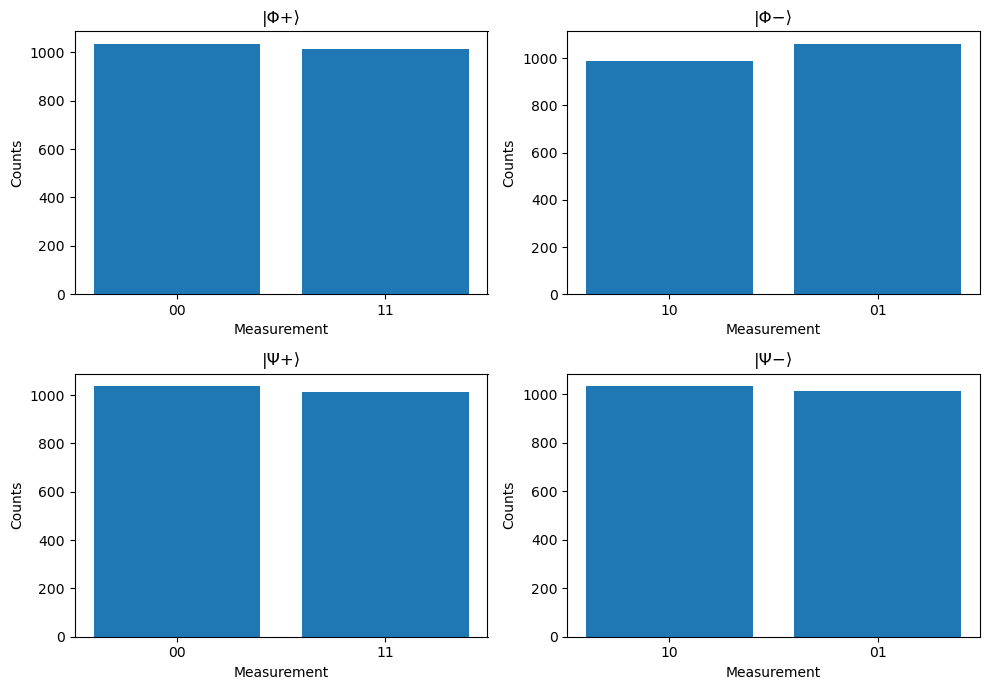

In [4]:
basis_results = {}

for state in states:
    qc, counts = run_bell(state, basis="hadamard", shots=2048)
    basis_results[state] = counts

    print(bell_names[state], "in Hadamard basis:")
    print(counts)
    print()

# Display selected results together
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for ax, state in zip(axes, states):
    counts = basis_results[state]
    labels = list(counts.keys())
    values = list(counts.values())

    ax.bar(labels, values)
    ax.set_title(bell_names[state])
    ax.set_xlabel("Measurement")
    ax.set_ylabel("Counts")

plt.tight_layout()
plt.show()
